# **PHÂN TÍCH: TAI NẠN GIAO THÔNG NEWYORK CITY 2020**

Người thực hiện: Võ Bạch Kim Thịnh

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/NYC Accidents 2020.csv")

Nguồn dữ liệu: NYC Traffic Accidents 2020 (https://mavenanalytics.io/data-playground/nyc-traffic-accidents)

Các vụ tai nạn giao thông do Sở Cảnh sát Thành phố New York báo cáo từ tháng 1 đến tháng 8 năm 2020. Mỗi bản ghi đại diện cho một vụ tai nạn riêng lẻ, bao gồm ngày, giờ và địa điểm xảy ra tai nạn (quận, mã bưu chính, tên đường, vĩ độ/kinh độ), các phương tiện và nạn nhân liên quan, và các yếu tố góp phần gây ra tai nạn.

In [ ]:
print("Kích thước bộ dữ liệu:",df.shape)

#hien thi 10 dong dau cua du lieu
print("\n10 dòng đầu của datasets: ")
display(df.head(10))

#hien thi 10 dong cuoi cua du lieu
print("\n10 dòng cuối của datasets: ")
display(df.tail(10))

Kích thước bộ dữ liệu: (74881, 29)

10 dòng đầu của datasets: 


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,2020-08-29,15:40:00,BRONX,10466.0,40.892100,-73.833760,POINT (-73.83376 40.8921),PRATT AVENUE,STRANG AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4342908,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
1,2020-08-29,21:00:00,BROOKLYN,11221.0,40.690500,-73.919914,POINT (-73.919914 40.6905),BUSHWICK AVENUE,PALMETTO STREET,NaN,...,Unspecified,NaN,NaN,NaN,4343555,Sedan,Sedan,NaN,NaN,NaN
2,2020-08-29,18:20:00,NaN,NaN,40.816500,-73.946556,POINT (-73.946556 40.8165),8 AVENUE,NaN,NaN,...,NaN,NaN,NaN,NaN,4343142,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
3,2020-08-29,00:00:00,BRONX,10459.0,40.824720,-73.892960,POINT (-73.89296 40.82472),NaN,NaN,1047 SIMPSON STREET,...,Unspecified,Unspecified,Unspecified,NaN,4343588,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,Sedan,Motorcycle,NaN
4,2020-08-29,17:10:00,BROOKLYN,11203.0,40.649890,-73.933890,POINT (-73.93389 40.64989),NaN,NaN,4609 SNYDER AVENUE,...,Unspecified,NaN,NaN,NaN,4342953,Sedan,Sedan,NaN,NaN,NaN
5,2020-08-29,03:29:00,NaN,NaN,40.682310,-73.844950,POINT (-73.84495 40.68231),WOODHAVEN BOULEVARD,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4342721,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
6,2020-08-29,19:30:00,BRONX,10459.0,40.825226,-73.887780,POINT (-73.88778 40.825226),LONGFELLOW AVENUE,EAST 165 STREET,NaN,...,NaN,NaN,NaN,NaN,4343004,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
7,2020-08-29,00:00:00,NaN,NaN,40.800160,-73.935380,POINT (-73.93538 40.80016),2 AVENUE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4343342,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
8,2020-08-29,19:50:00,BRONX,10466.0,40.894314,-73.860270,POINT (-73.86027 40.894314),EAST 233 STREET,CARPENTER AVENUE,NaN,...,Unspecified,Unspecified,NaN,NaN,4343030,Sedan,Station Wagon/Sport Utility Vehicle,Sedan,NaN,NaN
9,2020-08-29,09:20:00,QUEENS,11385.0,40.706780,-73.908880,POINT (-73.90888 40.70678),NaN,NaN,565 WOODWARD AVENUE,...,NaN,NaN,NaN,NaN,4343040,Sedan,NaN,NaN,NaN,NaN



10 dòng cuối của datasets: 


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
74871,2020-01-01,10:30:00,QUEENS,11427.0,40.728832,-73.746340,POINT (-73.74634 40.728832),NaN,NaN,218-05 HILLSIDE AVENUE,...,Unspecified,Unspecified,NaN,NaN,4268274,Sedan,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN
74872,2020-01-01,12:30:00,BROOKLYN,11214.0,40.599255,-73.989400,POINT (-73.9894 40.599255),86 STREET,24 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4267648,Station Wagon/Sport Utility Vehicle,Sedan,NaN,NaN,NaN
74873,2020-01-01,03:30:00,QUEENS,11435.0,40.695910,-73.809950,POINT (-73.80995 40.69591),CRESSKILL PLACE,97 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4267575,Sedan,Sedan,NaN,NaN,NaN
74874,2020-01-01,09:00:00,QUEENS,11420.0,40.664173,-73.812080,POINT (-73.81208 40.664173),NaN,NaN,129-06 OLD SOUTH ROAD,...,Unspecified,NaN,NaN,NaN,4267792,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
74875,2020-01-01,16:49:00,BROOKLYN,11234.0,40.609867,-73.922390,POINT (-73.92239 40.609867),NaN,NaN,5100 AVENUE U,...,Unspecified,NaN,NaN,NaN,4267821,Station Wagon/Sport Utility Vehicle,Sedan,NaN,NaN,NaN
74876,2020-01-01,15:13:00,BRONX,10459.0,40.826810,-73.896510,POINT (-73.89651 40.82681),NaN,NaN,1122 INTERVALE AVENUE,...,NaN,NaN,NaN,NaN,4268088,Sedan,NaN,NaN,NaN,NaN
74877,2020-01-01,08:00:00,BROOKLYN,11235.0,40.582935,-73.959210,POINT (-73.95921 40.582935),NaN,NaN,3401 GUIDER AVENUE,...,Unspecified,Unspecified,NaN,NaN,4267756,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,NaN
74878,2020-01-01,11:36:00,BRONX,10461.0,40.848553,-73.830055,POINT (-73.830055 40.848553),NaN,NaN,1810 MAHAN AVENUE,...,Unspecified,NaN,NaN,NaN,4269230,Sedan,Pick-up Truck,NaN,NaN,NaN
74879,2020-01-01,01:45:00,MANHATTAN,10017.0,40.753624,-73.969440,POINT (-73.96944 40.753624),EAST 48 STREET,2 AVENUE,NaN,...,Driver Inattention/Distraction,NaN,NaN,NaN,4267482,Sedan,Taxi,NaN,NaN,NaN
74880,2020-01-01,18:00:00,QUEENS,11367.0,40.726875,-73.830960,POINT (-73.83096 40.726875),NaN,NaN,70-25 PARK DRIVE EAST,...,Driver Inattention/Distraction,NaN,NaN,NaN,4268376,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN


In [ ]:
print("Thông tin bộ dữ liệu: ")
df.info()

Thông tin bộ dữ liệu: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74881 entries, 0 to 74880
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CRASH DATE                     74881 non-null  object 
 1   CRASH TIME                     74881 non-null  object 
 2   BOROUGH                        49140 non-null  object 
 3   ZIP CODE                       49134 non-null  float64
 4   LATITUDE                       68935 non-null  float64
 5   LONGITUDE                      68935 non-null  float64
 6   LOCATION                       68935 non-null  object 
 7   ON STREET NAME                 55444 non-null  object 
 8   CROSS STREET NAME              35681 non-null  object 
 9   OFF STREET NAME                19437 non-null  object 
 10  NUMBER OF PERSONS INJURED      74881 non-null  int64  
 11  NUMBER OF PERSONS KILLED       74881 non-null  int64  
 12  NUMBER OF PEDESTRIANS I

In [ ]:
print("Số giá trị thiếu: ")
print(df.isnull().sum())

Số giá trị thiếu: 
CRASH DATE                           0
CRASH TIME                           0
BOROUGH                          25741
ZIP CODE                         25747
LATITUDE                          5946
LONGITUDE                         5946
LOCATION                          5946
ON STREET NAME                   19437
CROSS STREET NAME                39200
OFF STREET NAME                  55444
NUMBER OF PERSONS INJURED            0
NUMBER OF PERSONS KILLED             0
NUMBER OF PEDESTRIANS INJURED        0
NUMBER OF PEDESTRIANS KILLED         0
NUMBER OF CYCLIST INJURED            0
NUMBER OF CYCLIST KILLED             0
NUMBER OF MOTORIST INJURED           0
NUMBER OF MOTORIST KILLED            0
CONTRIBUTING FACTOR VEHICLE 1      304
CONTRIBUTING FACTOR VEHICLE 2    15596
CONTRIBUTING FACTOR VEHICLE 3    68116
CONTRIBUTING FACTOR VEHICLE 4    73030
CONTRIBUTING FACTOR VEHICLE 5    74358
COLLISION_ID                         0
VEHICLE TYPE CODE 1                635
VEHICL

## Tiền xử lý dữ liệu

In [ ]:
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'])
df['Month'] = df['CRASH DATE'].dt.month
df['Hour'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M:%S', errors='coerce').dt.hour
df['DayOfWeek'] = df['CRASH DATE'].dt.day_name()

In [ ]:
cols_to_fill = ['BOROUGH', 'ON STREET NAME', 'CROSS STREET NAME', 'OFF STREET NAME',
                'CONTRIBUTING FACTOR VEHICLE 1']
for col in cols_to_fill:
    df[col] = df[col].fillna('Unknown')

In [ ]:
df['ON STREET NAME'] = df['ON STREET NAME'].fillna('Unknown')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74881 entries, 0 to 74880
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   CRASH DATE                     74881 non-null  datetime64[ns]
 1   CRASH TIME                     74881 non-null  object        
 2   BOROUGH                        74881 non-null  object        
 3   ZIP CODE                       49134 non-null  float64       
 4   LATITUDE                       68935 non-null  float64       
 5   LONGITUDE                      68935 non-null  float64       
 6   LOCATION                       68935 non-null  object        
 7   ON STREET NAME                 74881 non-null  object        
 8   CROSS STREET NAME              74881 non-null  object        
 9   OFF STREET NAME                74881 non-null  object        
 10  NUMBER OF PERSONS INJURED      74881 non-null  int64         
 11  NUMBER OF PERSO

## Visualization

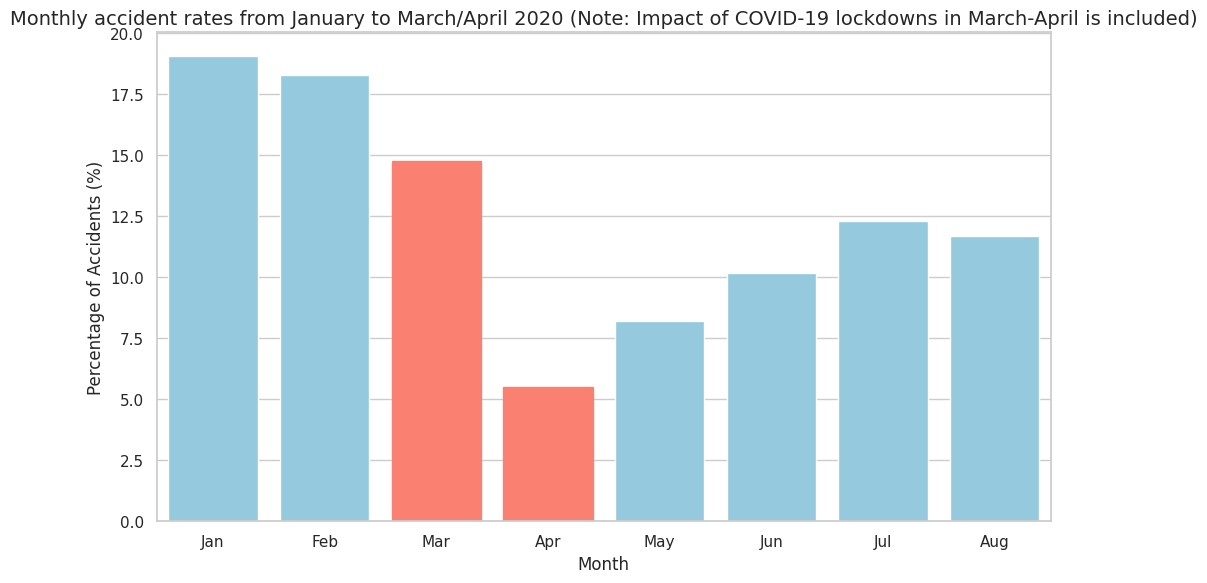

In [ ]:
monthly_counts = df['Month'].value_counts().sort_index()
monthly_pct = (monthly_counts / len(df)) * 100

plt.figure(figsize=(10, 6))
bars = sns.barplot(x=monthly_pct.index, y=monthly_pct.values, color='skyblue')
for i, bar in enumerate(bars.patches):
    if i + 1 in [3, 4]:
        bar.set_color('salmon') # Highlight March and April

plt.title('Monthly accident rates from January to March/April 2020 (Note: Impact of COVID-19 lockdowns in March-April is included)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Percentage of Accidents (%)', fontsize=12)
plt.xticks(ticks=range(len(monthly_counts)), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug'])
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

**Xu hướng theo tháng & Cú sốc COVID-19 (Biểu đồ cột)**

Phát hiện: Dữ liệu cho thấy một sự đứt gãy xu hướng rất rõ rệt. Sau khi duy trì ở mức cao trong hai tháng đầu năm, tỷ lệ tai nạn bắt đầu lao dốc mạnh vào Tháng 3 và "chạm đáy" vào Tháng 4 - ghi nhận mức thấp kỷ lục trong toàn bộ chuỗi dữ liệu.

Ý nghĩa: Sự sụt giảm bất thường này là minh chứng rõ nét cho tác động của đại dịch COVID-19. Lệnh phong tỏa (lockdown) toàn thành phố New York vào giữa tháng 3/2020, kết hợp với chính sách đóng cửa trường học và làm việc từ xa, đã khiến lưu lượng phương tiện trên đường giảm xuống mức thấp nhất. Khi số lượng xe cộ lưu thông gần như biến mất, rủi ro va chạm giao thông tự nhiên giảm xuống mức tối thiểu. Qua đó, ta thấy rõ mối tương quan thuận trực tiếp giữa mật độ giao thông và tần suất tai nạn.

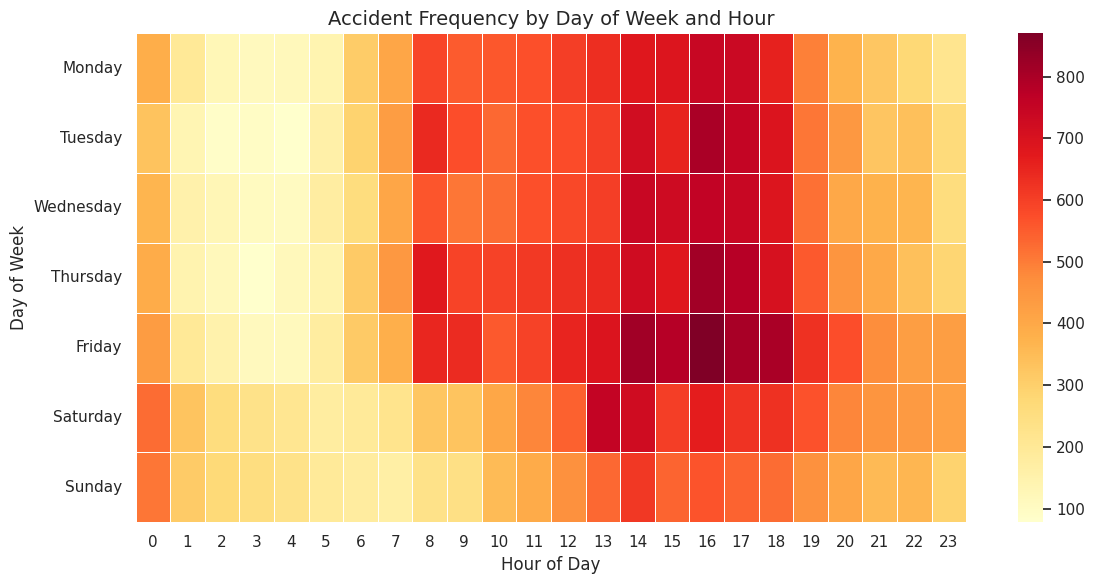

In [ ]:
heatmap_data = pd.crosstab(df['DayOfWeek'], df['Hour'])
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=.5)
plt.title('Accident Frequency by Day of Week and Hour', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_peaks.png')
plt.show()

**Phân tích Khung giờ & Ngày cao điểm (Biểu đồ Heatmap)**

Phát hiện: Điểm nóng (màu đậm nhất) rơi vào 14:00 đến 18:00 các ngày trong tuần, đặc biệt cao nhất vào chiều Thứ Sáu.

Ý nghĩa: Chiều tan tầm nguy hiểm hơn so với buổi sáng. Nguyên nhân có thể do sự mệt mỏi sau ngày dài làm việc, tầm nhìn giảm khi hoàng hôn, và tâm lý vội vã muốn về nhà (đặc biệt chiều Thứ Sáu).

/tmp/ipykernel_16278/2418060379.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_streets_pct.index, x=top_streets_pct.values, palette='viridis')


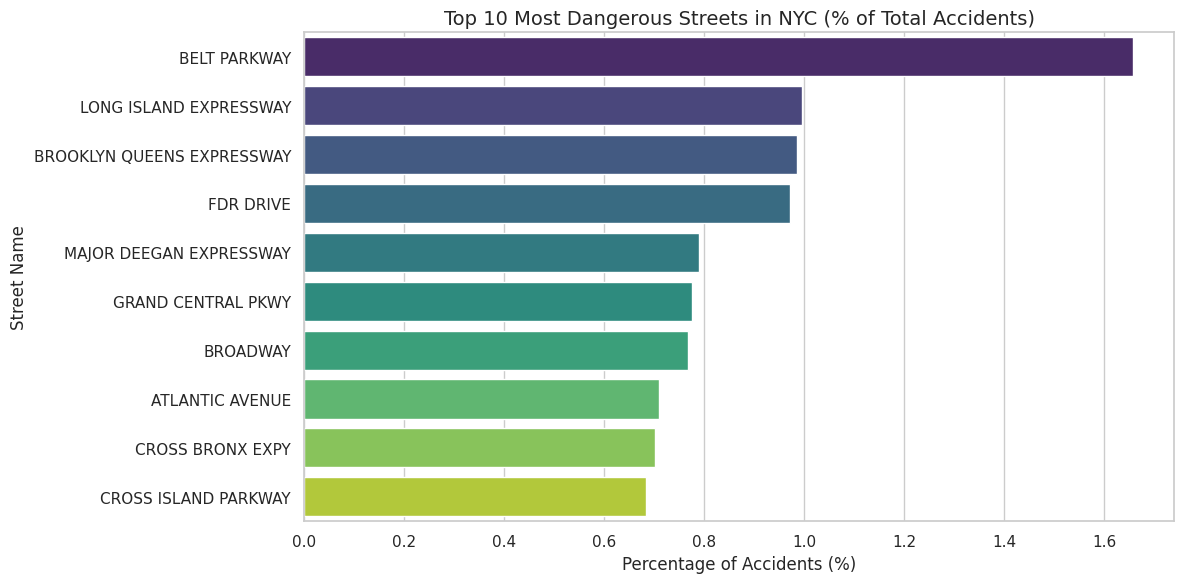

In [ ]:
streets = df[df['ON STREET NAME'] != 'Unknown']['ON STREET NAME']
top_streets_pct = (streets.value_counts().head(10) / len(df)) * 100

plt.figure(figsize=(12, 6))
sns.barplot(y=top_streets_pct.index, x=top_streets_pct.values, palette='viridis')
plt.title('Top 10 Most Dangerous Streets in NYC (% of Total Accidents)', fontsize=14)
plt.xlabel('Percentage of Accidents (%)', fontsize=12)
plt.ylabel('Street Name', fontsize=12)
plt.tight_layout()
plt.savefig('top_streets.png')
plt.show()

**Những tuyến đường tử thần (Biểu đồ cột ngang)**

Phát hiện: Tuyến đường Belt Parkway đứng đầu danh sách rủi ro với 1.241 vụ tai nạn (chiếm 1,65% trên tổng số 74.881 vụ toàn thành phố), theo sau là các tuyến Long Island Expressway và BQE.

Ý nghĩa: Con số 1,65% thoạt nhìn có vẻ nhỏ, nhưng thực tế đây là một tỷ lệ rất lớn và đáng báo động. Thành phố New York có hàng ngàn con đường và mạng lưới giao thông khổng lồ. Việc chỉ một tuyến đường duy nhất chiếm gần 2% tổng số vụ tai nạn của cả thành phố cho thấy sự tập trung rủi ro cực kỳ cao (điểm đen giao thông). Nguyên nhân là do đây đều là các đường cao tốc/đại lộ có lưu lượng phương tiện khổng lồ. Giao thông di chuyển tốc độ cao kết hợp với các điểm nhập/tách làn phức tạp khiến xác suất va chạm tại đây vượt trội so với các con đường thông thường.

/tmp/ipykernel_16278/1345641943.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=safest_streets['casualty_rate'] * 100, y=safest_streets.index, palette='Greens_r')


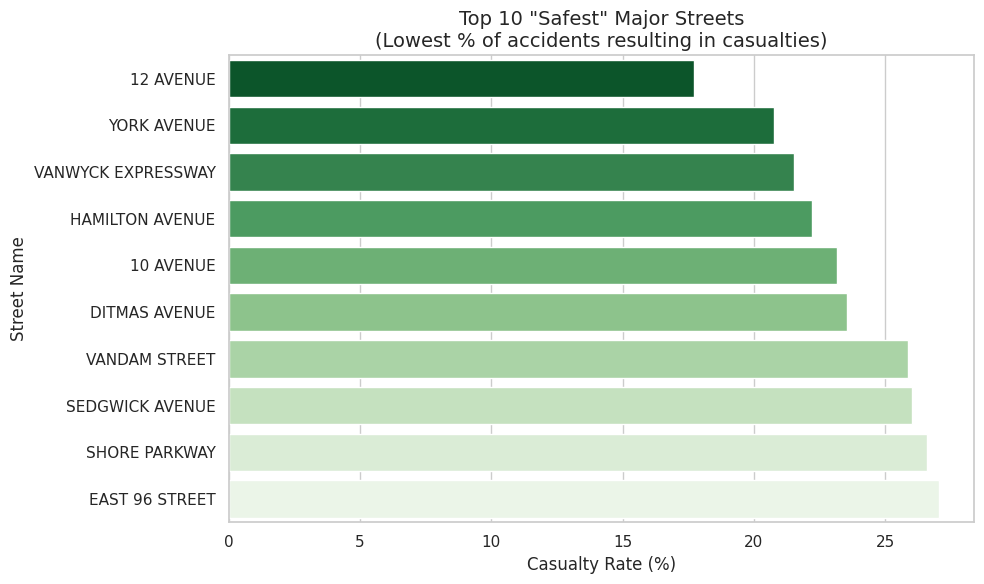

In [ ]:
street_stats = df[df['ON STREET NAME'] != 'Unknown'].groupby('ON STREET NAME').agg(
    total_accidents=('COLLISION_ID', 'count'),
    total_injured=('NUMBER OF PERSONS INJURED', 'sum'),
    total_killed=('NUMBER OF PERSONS KILLED', 'sum')
)
# Calculate casualties and rate
street_stats['casualties'] = street_stats['total_injured'] + street_stats['total_killed']
street_stats['casualty_rate'] = street_stats['casualties'] / street_stats['total_accidents']

# Filter for major streets (>= 50 accidents) and get the safest 10
major_streets = street_stats[street_stats['total_accidents'] >= 50]
safest_streets = major_streets.sort_values('casualty_rate').head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=safest_streets['casualty_rate'] * 100, y=safest_streets.index, palette='Greens_r')
plt.title('Top 10 "Safest" Major Streets\n(Lowest % of accidents resulting in casualties)', fontsize=14)
plt.xlabel('Casualty Rate (%)', fontsize=12)
plt.ylabel('Street Name', fontsize=12)
plt.tight_layout()
plt.savefig('safest_streets.png')
plt.show()

**Top 10 Tuyến đường lớn "An toàn nhất" (Biểu đồ cột màu xanh)**

Lưu ý về phương pháp: Để đo lường "độ an toàn", chúng ta không thể chỉ lọc các đường có số vụ tai nạn thấp nhất (vì có hàng ngàn con hẻm nhỏ chỉ có 1 vụ va chạm). Do đó, biểu đồ này xét trên tiêu chí: Tỷ lệ thương vong (Casualty Rate) thấp nhất trong số các tuyến đường lớn (có từ 50 vụ tai nạn trở lên).

Phát hiện: Tuyến đường 12 Avenue được ghi nhận là an toàn nhất với tỷ lệ thương vong chỉ khoảng 17,7% (tức là cứ 100 vụ va chạm ở đây thì chỉ có chưa tới 18 vụ có người bị thương/tử vong, còn lại chủ yếu là va quẹt xe nhẹ). Theo sau là York Avenue và Van Wyck Expressway.

Ý nghĩa: Điều này cho thấy mặc dù những tuyến đường này có lưu lượng giao thông đông và xảy ra nhiều va chạm (ví dụ Van Wyck Expressway có 158 vụ), nhưng mức độ nghiêm trọng của các vụ tai nạn lại rất thấp. Đây có thể là kết quả của việc tổ chức giao thông tốt, giới hạn tốc độ hiệu quả hoặc tình trạng kẹt xe thường xuyên khiến các phương tiện không thể di chuyển ở tốc độ nguy hiểm.

/tmp/ipykernel_16278/4002614130.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_factors_regular.index, x=top_factors_regular.values, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_16278/4002614130.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_factors_fatal.index, x=top_factors_fatal.values, ax=axes[1], palette='Reds_r')


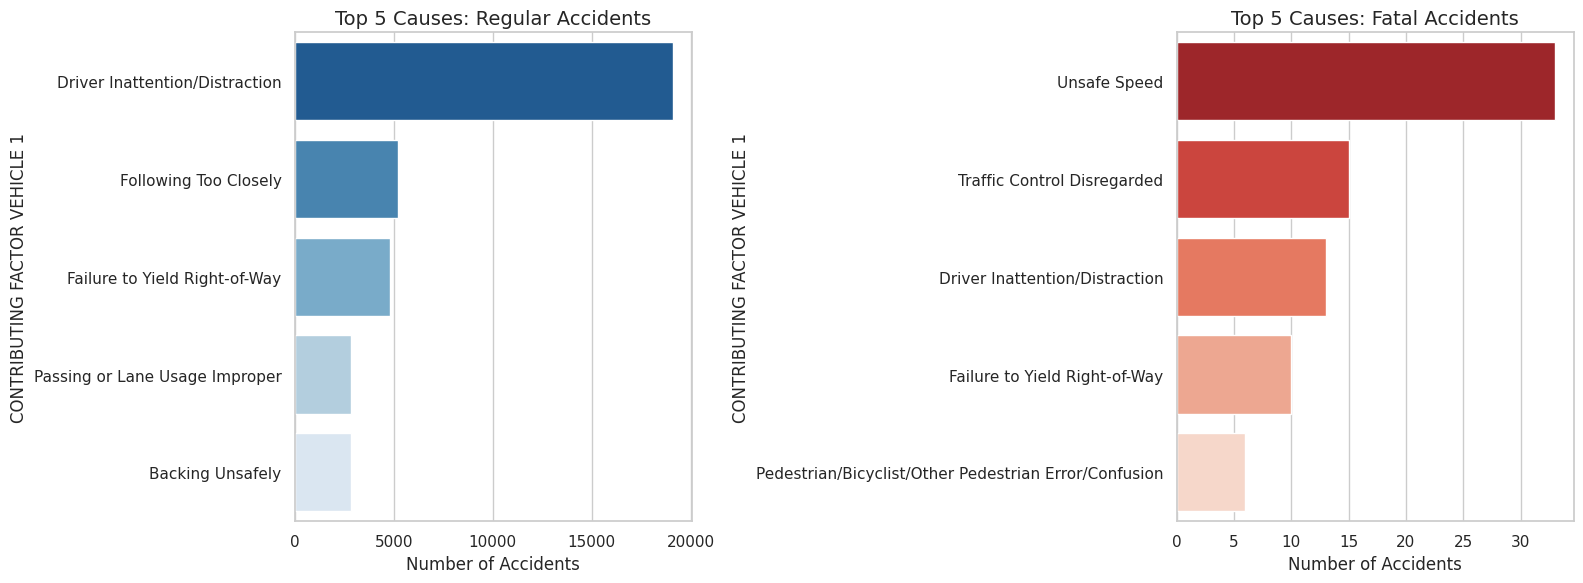

In [ ]:
fatal_df = df[df['NUMBER OF PERSONS KILLED'] > 0]
regular_df = df[df['NUMBER OF PERSONS KILLED'] == 0]

top_factors_fatal = fatal_df[~fatal_df['CONTRIBUTING FACTOR VEHICLE 1'].isin(['Unspecified', 'Unknown'])]['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().head(5)
top_factors_regular = regular_df[~regular_df['CONTRIBUTING FACTOR VEHICLE 1'].isin(['Unspecified', 'Unknown'])]['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().head(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(y=top_factors_regular.index, x=top_factors_regular.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 5 Causes: Regular Accidents', fontsize=14)
axes[0].set_xlabel('Number of Accidents')

sns.barplot(y=top_factors_fatal.index, x=top_factors_fatal.values, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 5 Causes: Fatal Accidents', fontsize=14)
axes[1].set_xlabel('Number of Accidents')
plt.tight_layout()
plt.savefig('causes_comparison.png')
plt.show()

**So sánh Nguyên nhân - Tai nạn thông thường vs. Chết người (Biểu đồ song song)**

Phát hiện: "Tài xế xao nhãng" (Driver Inattention) là nguyên nhân gây ra nhiều vụ tai nạn nhẹ nhất. Tuy nhiên, đối với tai nạn chết người, "Tốc độ không an toàn" (Unsafe Speed) lại chiếm vị trí số 1.

Ý nghĩa: Xao nhãng dễ gây ra va chạm nhẹ, nhưng chính tốc độ là yếu tố làm tăng động năng va chạm, giảm thời gian phản xạ và quyết định tỷ lệ tử vong cao nhất.

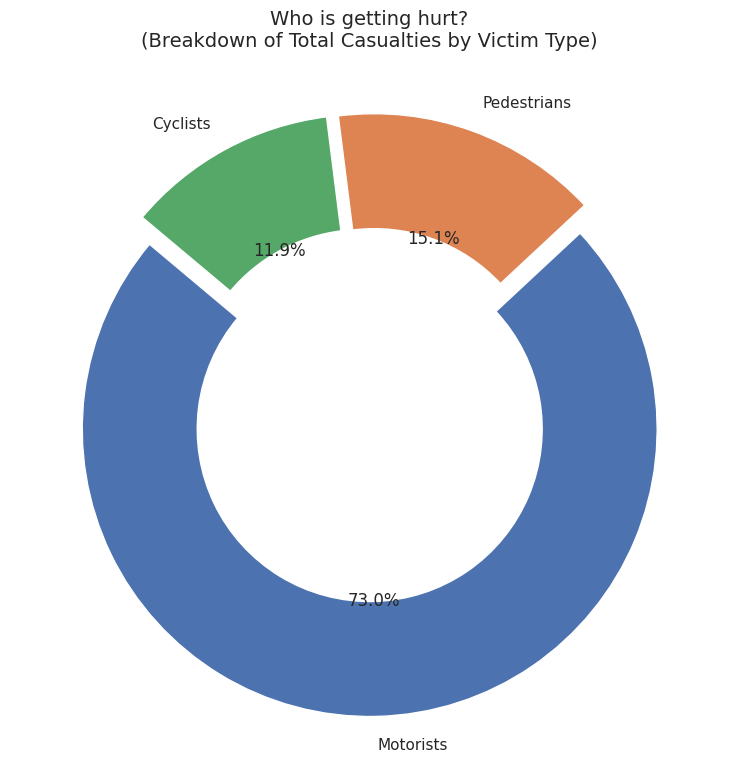

In [ ]:
victims = {
    'Motorists': df['NUMBER OF MOTORIST INJURED'].sum() + df['NUMBER OF MOTORIST KILLED'].sum(),
    'Pedestrians': df['NUMBER OF PEDESTRIANS INJURED'].sum() + df['NUMBER OF PEDESTRIANS KILLED'].sum(),
    'Cyclists': df['NUMBER OF CYCLIST INJURED'].sum() + df['NUMBER OF CYCLIST KILLED'].sum()
}
victims_df = pd.Series(victims).reset_index()
victims_df.columns = ['Victim Type', 'Count']

plt.figure(figsize=(8, 8))
plt.pie(victims_df['Count'], labels=victims_df['Victim Type'], autopct='%1.1f%%',
        colors=['#4C72B0', '#DD8452', '#55A868'], startangle=140, explode=(0.05, 0.05, 0.05),
        wedgeprops=dict(width=0.4, edgecolor='w')) # Donut style
plt.title('Who is getting hurt?\n(Breakdown of Total Casualties by Victim Type)', fontsize=14)
plt.tight_layout()
plt.savefig('casualty_breakdown.png')
plt.show()

**Phân tích Nạn nhân - Ai là người bị thương? (Biểu đồ Donut)**

Phát hiện: Trong tổng số người bị thương vong do tai nạn giao thông tại NYC năm 2020, nhóm người ngồi trên xe cơ giới (Motorists) chiếm tỷ lệ áp đảo với 73% (hơn 20.000 người). Nhóm người đi bộ (Pedestrians) chiếm 15.1% và người đi xe đạp (Cyclists) chiếm 11.9%.

Ý nghĩa: Biểu đồ này chỉ ra mức độ rủi ro đối với nhóm người tham gia giao thông yếu thế (Vulnerable Road Users). Mặc dù người đi bộ và người đi xe đạp chỉ chiếm tổng cộng 27% số ca thương vong, nhưng hậu quả đối với họ thường nghiêm trọng hơn rất nhiều do không có vỏ bọc bảo vệ như người ngồi trong ô tô. Đây là một cơ sở dữ liệu quan trọng để đề xuất các chính sách quy hoạch đô thị (ví dụ như xây dựng làn đường riêng cho xe đạp hoặc mở rộng lề đường cho người đi bộ).

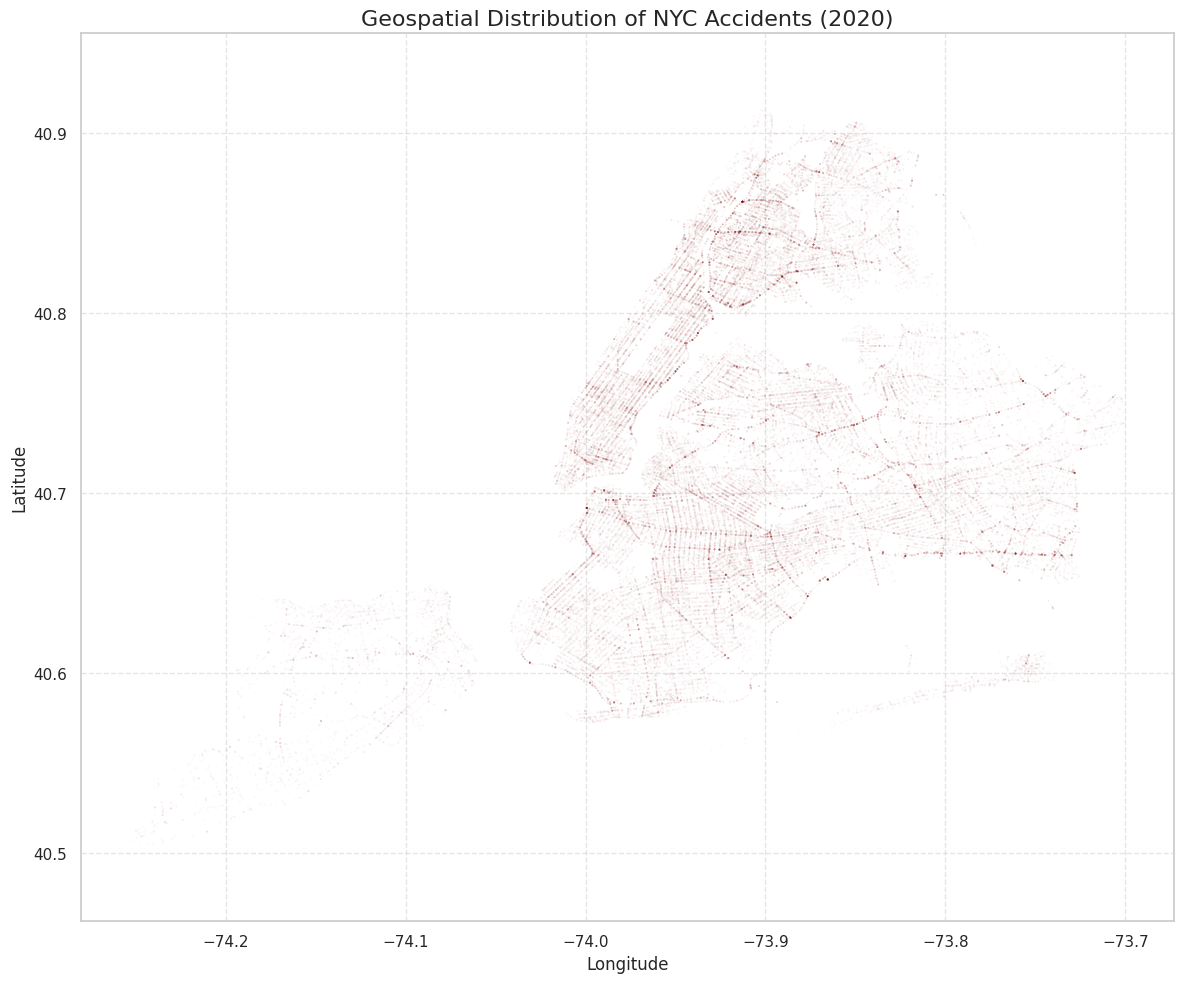

In [ ]:
# Filter coordinates within NYC bounding box
nyc_bounds = (df['LATITUDE'] > 40.4) & (df['LATITUDE'] < 40.95) & (df['LONGITUDE'] > -74.3) & (df['LONGITUDE'] < -73.6)
map_df = df[nyc_bounds]

plt.figure(figsize=(12, 10))
# Scatter plot with low alpha to show density and hot spots
plt.scatter(map_df['LONGITUDE'], map_df['LATITUDE'], alpha=0.03, s=2, c='darkred', edgecolors='none')

plt.title('Geospatial Distribution of NYC Accidents (2020)', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.axis('equal') # Keep the map aspect ratio correct
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nyc_map.png', dpi=300)
plt.show()

**Phân bổ Địa lý (Biểu đồ Bản đồ NYC)**

Phát hiện: Các điểm đỏ tập trung dày đặc nhất ở khu vực trung tâm Manhattan và chạy dọc theo các tuyến đường vành đai/cao tốc nối liền Brooklyn và Queens. Các vùng ven ngoại ô (Staten Island) hiển thị mật độ tai nạn thưa thớt hơn hẳn.

Ý nghĩa: Mật độ tai nạn tương quan trực tiếp với mật độ dân cư và lưu lượng xe thương mại. Nơi nào có hoạt động kinh tế, giao thương càng sầm uất thì xác suất xảy ra va chạm càng dày đặc. Chức năng `alpha=0.03` trong code tạo ra hiệu ứng Heatmap, giúp chỉ ra chính xác các trục giao thông trọng yếu của thành phố.

In [ ]:
# tạo target (biến dự đoán)
df['injury_flag'] = (df['NUMBER OF PERSONS INJURED'] > 0).astype(int)
df['injury_flag'].value_counts()

,count
injury_flag,
0,54460
1,20421


Biến injury_flag được tạo để phân loại tai nạn có gây thương tích hay không và chuyển bài toán thành bài toán phân loại nhị phân.

Tổng số vụ tai nạn là 68,935 vụ.
* Giá trị 0 (50,203): Có 50,203 vụ tai nạn không gây thương vong (không có ai bị thương hoặc tử vong) chiếm khoảng 72.8%. Đây là các vụ tai nạn chỉ gây thiệt hại về tài sản hoặc va chạm nhẹ.

* Giá trị 1 (18,732): Có 18,732 vụ tai nạn chiếm khoảng 27.2%. Có ít nhất một người bị thương hoặc tử vong.

<Axes: xlabel='injury_flag', ylabel='count'>

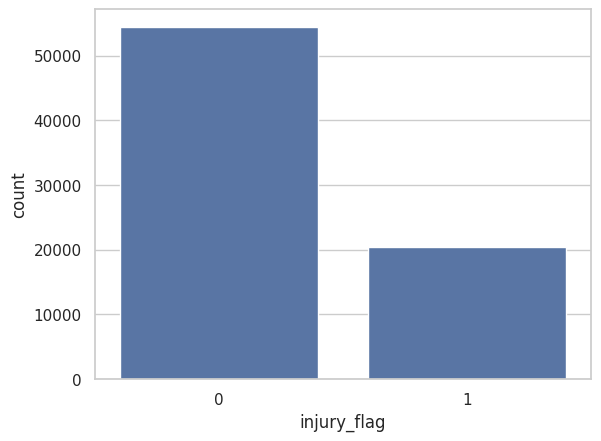

In [ ]:
#kiểm tra xem dữ liệu có bị lệch hay
import seaborn as sns
sns.countplot(x=df['injury_flag'])

Biểu đồ cho thấy số lượng tai nạn không gây thương tích (0) nhiều hơn tai nạn gây thương tích (1), cho thấy dữ liệu bị lệch lớp nhẹ.

Số lượng vụ "không thương tích" (0) nhiều gấp gần 3 lần số vụ "có thương tích" (1).

In [ ]:
# xu ly du lieu
df.columns = df.columns.str.strip()
df['BOROUGH'] = df['BOROUGH'].fillna('Unknown')
df = df.dropna(subset=['CRASH DATE','CRASH TIME','LATITUDE','LONGITUDE'])

Phần này dùng để làm sạch dữ liệu trước khi xây dựng mô hình:

* Chuẩn hóa tên cột bằng str.strip() để tránh lỗi truy cập dữ liệu do khoảng trắng thừa.
* Thay giá trị thiếu của biến BOROUGH bằng "Unknown" nhằm giữ lại dữ liệu thay vì xóa dòng.
* Loại bỏ các dòng thiếu CRASH DATE, CRASH TIME, LATITUDE, LONGITUDE vì đây là các biến quan trọng để xác định thời gian và vị trí tai nạn.

 Mục tiêu: đảm bảo dữ liệu đầy đủ và chính xác trước khi huấn luyện mô hình.

In [ ]:
#tao crash_datetime
df['CRASH_DATETIME'] = pd.to_datetime(
    df['CRASH DATE'].astype(str) + ' ' + df['CRASH TIME'],
    errors='coerce'
)

df['Hour'] = df['CRASH_DATETIME'].dt.hour
df['Month'] = df['CRASH_DATETIME'].dt.month
df['Weekday'] = df['CRASH_DATETIME'].dt.day_name()

Sau khi dữ liệu đã được làm sạch, hai biến CRASH DATE và CRASH TIME được kết hợp lại thành một biến thời gian đầy đủ có tên là CRASH_DATETIME. Việc kết hợp này giúp chuyển dữ liệu thời gian về đúng định dạng datetime, từ đó có thể trích xuất thêm nhiều đặc trưng thời gian phục vụ cho mô hình học máy.

Từ biến CRASH_DATETIME, ba biến mới được tạo ra gồm:

* Hour: thể hiện giờ xảy ra tai nạn trong ngày
* Month: thể hiện tháng xảy ra tai nạn trong năm
* Weekday: thể hiện ngày trong tuần xảy ra tai nạn

Các biến này đóng vai trò rất quan trọng vì tai nạn giao thông thường phụ thuộc nhiều vào yếu tố thời gian. Việc trích xuất các đặc trưng thời gian giúp mô hình học được các quy luật này và cải thiện khả năng dự đoán.

Ngoài ra, việc chuyển dữ liệu thời gian sang dạng số hoặc dạng phân loại như Hour, Month và Weekday cũng giúp các thuật toán học máy xử lý dữ liệu hiệu quả hơn so với việc sử dụng trực tiếp chuỗi thời gian ban đầu.

In [ ]:
# tạo target
df['injury_flag'] = (df['NUMBER OF PERSONS INJURED'] > 0).astype(int)
features = [
    'Hour',
    'Month',
    'Weekday',
    'BOROUGH',
    'LATITUDE',
    'LONGITUDE'
]

X = df[features]
y = df['injury_flag']

Tạo biến **injury_flag**, nhằm xác định liệu một vụ tai nạn có gây thương tích hay không.

Cụ thể:

* Nếu có người bị thương → gán giá trị 1
* Nếu không có người bị thương → gán giá trị 0

Giúp chuyển bài toán thành bài toán phân loại nhị phân, để mô hình dự đoán khả năng xảy ra thương tích trong tai nạn giao thông.

* Thời điểm xảy ra tai nạn (Hour, Month, Weekday)
* Khu vực xảy ra tai nạn (BOROUGH)
* Vị trí địa lý (LATITUDE, LONGITUDE)

Những yếu tố này có ảnh hưởng trực tiếp đến khả năng xảy ra tai nạn nghiêm trọng. Đây là bước lựa chọn đặc trưng cho mô hình, giúp mô hình học hiệu quả hơn.

Trong đó:
* X: chứa các biến đầu vào cho mô hình

* y: chứa biến mục tiêu cần dự đoán

In [ ]:
#train test list
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.impute import SimpleImputer

# Thực hiện one-hot encoding cho cả Weekday và BOROUGH
cats_to_encode = ['Weekday', 'BOROUGH']

X_train_processed = pd.get_dummies(
    X_train,
    columns=cats_to_encode,
    drop_first=True
)

X_test_processed = pd.get_dummies(
    X_test,
    columns=cats_to_encode,
    drop_first=True
)

# Đồng bộ các cột giữa tập train và test
train_cols = X_train_processed.columns
for col in train_cols:
    if col not in X_test_processed.columns:
        X_test_processed[col] = 0
X_test_processed = X_test_processed[train_cols]

# Xử lý giá trị thiếu cho Latitude và Longitude
imputer = SimpleImputer(strategy='mean')
cols_nan = ['LATITUDE', 'LONGITUDE']

imputer.fit(X_train_processed[cols_nan])
X_train_processed[cols_nan] = imputer.transform(X_train_processed[cols_nan])
X_test_processed[cols_nan] = imputer.transform(X_test_processed[cols_nan])

**Mô hình Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model_lr.fit(X_train_processed, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

===== LOGISTIC REGRESSION =====
Accuracy: 0.5724232973090593

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.58      0.66     10041
           1       0.33      0.55      0.41      3746

    accuracy                           0.57     13787
   macro avg       0.55      0.57      0.54     13787
weighted avg       0.66      0.57      0.60     13787



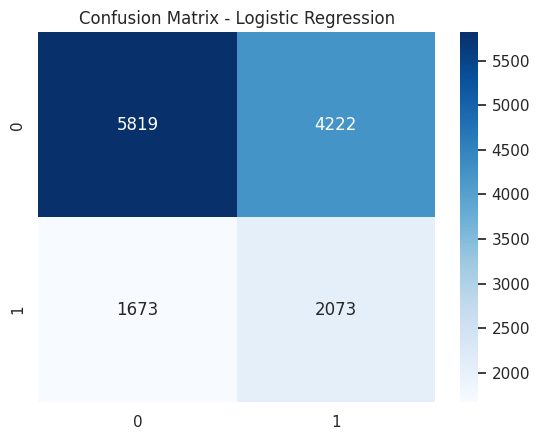

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_lr = model_lr.predict(X_test_processed)

print("===== LOGISTIC REGRESSION =====")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Mô hình Logistic Regression đạt độ chính xác tổng thể 57.24%.

Đối với lớp không có thương tích (0), mô hình đạt precision 78% và recall 58%, cho thấy khả năng dự đoán tương đối tốt.

Đối với lớp có thương tích (1), mô hình đạt recall 55%, nghĩa là phát hiện được hơn một nửa số vụ tai nạn có thương tích. Tuy nhiên precision chỉ đạt 33%, cho thấy vẫn còn nhiều trường hợp dự đoán sai. Điều này phản ánh sự mất cân bằng giữa hai lớp dữ liệu trong dataset.

Nhìn chung, Logistic Regression cho khả năng phát hiện tai nạn có thương tích ở mức trung bình và có thể sử dụng làm mô hình cơ sở để so sánh với các mô hình nâng cao hơn.

**Mô hình Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model_rf.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)


===== RANDOM FOREST =====
Accuracy: 0.7016029593094945

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.92      0.82     10041
           1       0.36      0.12      0.18      3746

    accuracy                           0.70     13787
   macro avg       0.55      0.52      0.50     13787
weighted avg       0.63      0.70      0.64     13787



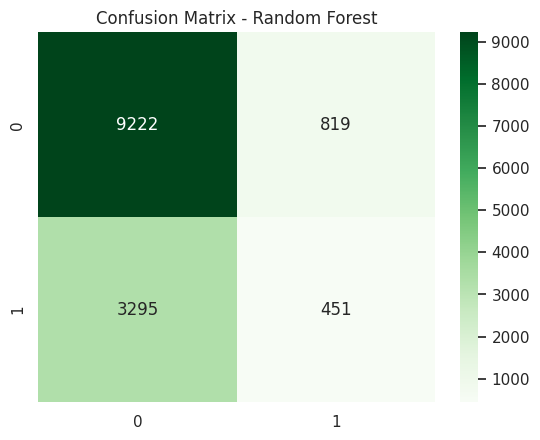

In [ ]:
y_pred_rf = model_rf.predict(X_test_processed)

print("\n===== RANDOM FOREST =====")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()

Mô hình Random Forest đạt độ chính xác tổng thể 70.16%, cao hơn Logistic Regression. Tuy nhiên khả năng phát hiện các trường hợp tai nạn có thương tích rất thấp với recall chỉ đạt 12%. Điều này cho thấy mô hình có xu hướng dự đoán thiên về lớp không có thương tích do dữ liệu mất cân bằng giữa hai lớp. Vì vậy mặc dù Random Forest cho độ chính xác tổng thể cao hơn, Logistic Regression lại phù hợp hơn trong việc phát hiện các vụ tai nạn nghiêm trọng.

**Mô hình XGBoost**

In [ ]:
# khoi chay mô hình
!pip install xgboost

In [ ]:
# train mô hình
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

model_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_xgb.fit(X_train_processed, y_train)

y_pred_xgb = model_xgb.predict(X_test_processed)

print("===== XGBoost Result =====")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:45:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


===== XGBoost Result =====
Accuracy: 0.5629215928048161

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.55      0.65     10041
           1       0.33      0.59      0.42      3746

    accuracy                           0.56     13787
   macro avg       0.56      0.57      0.54     13787
weighted avg       0.66      0.56      0.59     13787



Trong ba mô hình được thử nghiệm, Random Forest đạt độ chính xác tổng thể cao nhất nhưng khả năng phát hiện các trường hợp tai nạn có thương tích rất thấp. Logistic Regression cải thiện khả năng phát hiện tai nạn nghiêm trọng nhưng độ chính xác tổng thể chưa cao. Mô hình XGBoost cho kết quả tốt nhất với recall đạt 59% và F1-score đạt 0.42 đối với lớp có thương tích, cho thấy khả năng phát hiện tai nạn nguy hiểm hiệu quả hơn so với hai mô hình còn lại. Vì vậy XGBoost được lựa chọn là mô hình phù hợp nhất cho bài toán dự đoán mức độ nghiêm trọng của tai nạn giao thông.

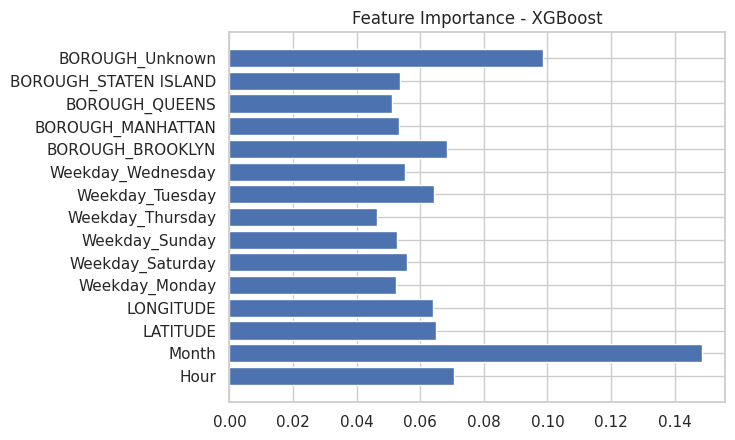

In [ ]:
#bieu do feature importance
importance = model_xgb.feature_importances_

plt.barh(X_train_processed.columns, importance)
plt.title("Feature Importance - XGBoost")
plt.show()

Biểu đồ Feature Importance của mô hình XGBoost cho thấy biến Month có mức độ ảnh hưởng lớn nhất đến khả năng xảy ra tai nạn có thương tích, tiếp theo là các biến liên quan đến khu vực như BOROUGH và thời điểm xảy ra tai nạn như Hour. Ngoài ra, các biến vị trí địa lý LATITUDE và LONGITUDE cũng đóng vai trò quan trọng trong việc xác định mức độ nghiêm trọng của tai nạn. Điều này cho thấy yếu tố thời gian và vị trí có ảnh hưởng đáng kể đến nguy cơ xảy ra tai nạn giao thông có thương tích.

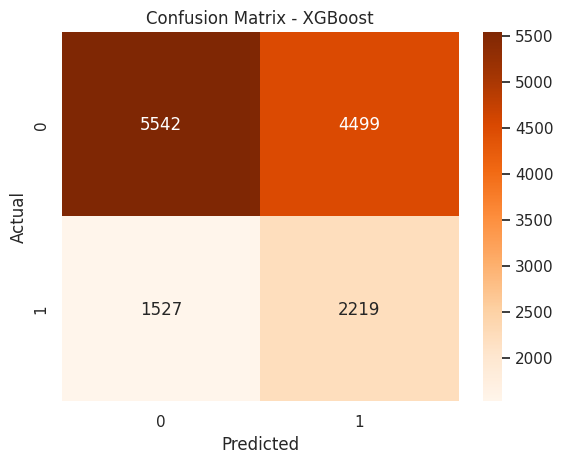

In [ ]:
#truc quan hoa mô hinh
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Ma trận nhầm lẫn của mô hình XGBoost cho thấy mô hình dự đoán đúng 2219 trường hợp tai nạn có thương tích và bỏ sót 1527 trường hợp. Ngoài ra mô hình dự đoán sai 4499 trường hợp không có thương tích thành có thương tích, cho thấy mô hình có xu hướng cảnh báo nhiều hơn nhằm giảm nguy cơ bỏ sót các tai nạn nghiêm trọng. Điều này giúp tăng khả năng phát hiện tai nạn nguy hiểm và phù hợp với mục tiêu của bài toán dự đoán mức độ nghiêm trọng của tai nạn giao thông.

**So sánh các mô hình**

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
xgb_report = classification_report(y_test, y_pred_xgb, output_dict=True)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Recall (injury=1)",
        "Precision (injury=1)",
        "F1-score (injury=1)"
    ],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        lr_report['1']['recall'],
        lr_report['1']['precision'],
        lr_report['1']['f1-score']
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        rf_report['1']['recall'],
        rf_report['1']['precision'],
        rf_report['1']['f1-score']
    ],
    "XGBoost": [
        accuracy_score(y_test, y_pred_xgb),
        xgb_report['1']['recall'],
        xgb_report['1']['precision'],
        xgb_report['1']['f1-score']
    ]
})

comparison

,Metric,Logistic Regression,Random Forest,XGBoost
0,Accuracy,0.572423,0.701603,0.562922
1,Recall (injury=1),0.553390,0.120395,0.592365
2,Precision (injury=1),0.329309,0.355118,0.330307
3,F1-score (injury=1),0.412907,0.179825,0.424121


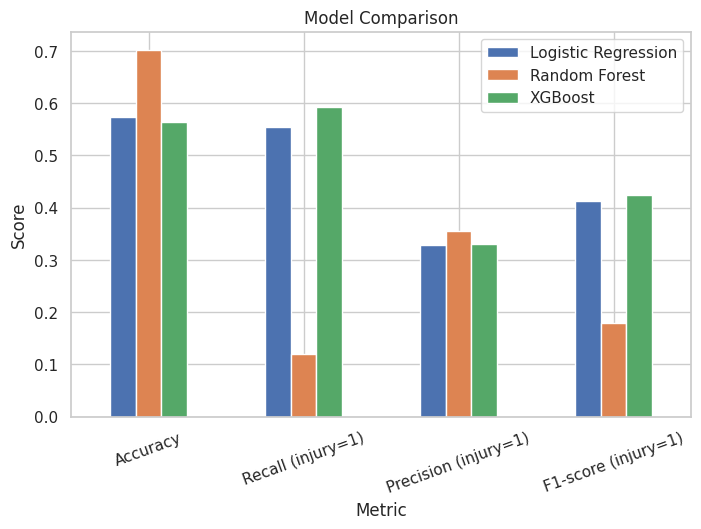

In [ ]:
comparison.set_index("Metric").plot(kind="bar", figsize=(8,5))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)

plt.show()

Kết quả so sánh cho thấy Random Forest đạt độ chính xác tổng thể cao nhất (70.16%), tuy nhiên khả năng phát hiện các trường hợp tai nạn có thương tích rất thấp với recall chỉ đạt 12%. Logistic Regression cải thiện khả năng phát hiện tai nạn nghiêm trọng với recall đạt 55.3%. Trong khi đó, mô hình XGBoost đạt recall cao nhất (59.2%) và F1-score cao nhất (0.424) đối với lớp có thương tích, cho thấy hiệu quả phân loại tốt nhất. Do đó XGBoost được lựa chọn là mô hình phù hợp nhất cho bài toán dự đoán mức độ nghiêm trọng của tai nạn giao thông.

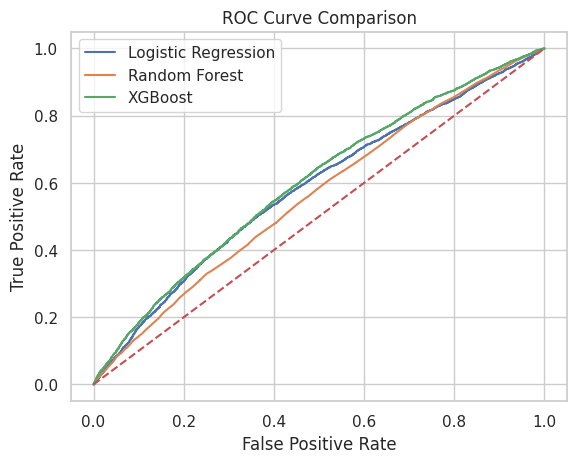

In [ ]:
#Biểu đồ ROC Curve
from sklearn.metrics import roc_curve

y_prob_lr = model_lr.predict_proba(X_test_processed)[:,1]
y_prob_rf = model_rf.predict_proba(X_test_processed)[:,1]
y_prob_xgb = model_xgb.predict_proba(X_test_processed)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.plot([0,1],[0,1],'--')

plt.legend()
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()


###  Mục tiêu của biểu đồ ROC
Biểu đồ giúp đánh giá khả năng **phân biệt** giữa tai nạn có thương tích (1) và không có thương tích (0) của 3 mô hình: **XGBoost, Logistic Regression và Random Forest.**

### Ý nghĩa các thành phần chính
* **Trục đứng (Y - True Positive Rate (TPR)):** Tỷ lệ dự đoán **đúng** số vụ tai nạn có thương tích. Chỉ số này càng cao, mô hình càng nhạy bén trong việc phát hiện nguy hiểm.
* **Trục ngang (X - False Positive Rate (FPR)):** Tỷ lệ dự đoán **nhầm** tai nạn bình thường thành có thương tích. Chỉ số này càng thấp, mô hình càng ít sai sót.
* **Đường chéo đỏ (nét đứt):** Ngưỡng "đoán mò". Mọi đường biểu đồ nằm trên đường này đều cho thấy mô hình có học được dữ liệu.


### So sánh và Đánh giá 3 mô hình
Nguyên tắc: **Đường nào nằm gần góc trên bên trái nhất là mô hình tốt nhất.**

* **XGBoost (Màu xanh lá) - Tối ưu nhất:** Nằm cao nhất trên biểu đồ. Điều này chứng tỏ XGBoost có khả năng phát hiện các vụ tai nạn nguy hiểm hiệu quả hơn hẳn hai mô hình còn lại tại cùng một mức độ sai sót.
* **Logistic Regression (Màu xanh dương) - Trung bình:** Nằm ở giữa, cho thấy khả năng phân loại ở mức ổn định nhưng chưa đạt độ chính xác cao như XGBoost.
* **Random Forest (Màu cam) - Thấp nhất:** Đường này nằm thấp nhất (gần đường dự đoán ngẫu nhiên nhất), cho thấy mô hình này gặp khó khăn trong việc phân biệt các vụ tai nạn có thương tích trong bộ dữ liệu này.

### Kết luận
Dựa trên hình dạng đường ROC, **XGBoost là mô hình chiến thắng.** Trong bài toán tai nạn giao thông (dữ liệu thường bị lệch vì số vụ không thương tích nhiều hơn), ROC Curve là minh chứng rõ ràng nhất cho thấy XGBoost vượt trội trong việc "nhận diện" các vụ tai nạn nguy hiểm, giúp đưa ra các cảnh báo chính xác hơn cho công tác an toàn giao thông.